# ETL Examination
Inspect the arXiv abstracts stored in S3 after the ETL run.

In [1]:
import json
import random
import os
import boto3
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

s3 = boto3.client('s3', region_name=os.environ.get('AWS_REGION', 'us-east-2'))
bucket = os.environ['S3_BUCKET']

def load_jsonl(key):
    obj = s3.get_object(Bucket=bucket, Key=key)
    lines = obj['Body'].read().decode('utf-8').strip().splitlines()
    return [json.loads(l) for l in lines]

train = load_jsonl('materialLLM/data/arxiv/train.jsonl')
val   = load_jsonl('materialLLM/data/arxiv/val.jsonl')

print(f"Train: {len(train)} records")
print(f"Val:   {len(val)} records")

Train: 900 records
Val:   100 records


## Schema — what fields does each record have?

In [2]:
print("Fields:", list(train[0].keys()))
print()
print(json.dumps(train[0], indent=2))

Fields: ['id', 'title', 'text', 'published', 'source']

{
  "id": "http://arxiv.org/abs/2606.14213v1",
  "title": "Vapor-to-glass preparation of biaxially aligned organic semiconductors",
  "text": "Physical vapor deposition (PVD) provides a route to prepare highly stable and anisotropic organic glasses that are utilized in multi-layer structures such as organic light-emitting devices. While previous work has demonstrated that anisotropic glasses with uniaxial symmetry can be prepared by PVD, here, we prepare biaxially aligned glasses in which molecular orientation has a preferred in-plane direction. With the collective effect of the surface equilibration mechanism and template growth on an aligned substrate, macroscopic biaxial alignment is achieved in depositions as much as 180 K below the clearing point $T_{LC-iso}$ (and 50 K below the glass transition temperature $T_g$ ) with single-component disk-like (phenanthroperylene ester) and rod-like (itraconazole) mesogens. The preparation

## 5 random samples

In [3]:
for doc in random.sample(train, 5):
    print(f"TITLE:     {doc['title']}")
    print(f"PUBLISHED: {doc['published']}")
    print(f"ID:        {doc['id']}")
    print(f"TEXT:      {doc['text'][:400]}")
    print("-" * 80)

TITLE:     Co-optimization of spin coherence and valley splitting in Si/SiGe heterostructures
PUBLISHED: 2026-05-29T14:20:52Z
ID:        http://arxiv.org/abs/2605.31342v1
TEXT:      Single electron spins can be used to encode and process information in semiconductor quantum devices. Progress has been hindered by materials challenges, such as the small energy splitting between low-lying valley states and hyperfine coupling to nuclear spins. Here we use density functional theory to optimize the valley splitting and spin dephasing time in realistic Si/SiGe heterostructures. Redu
--------------------------------------------------------------------------------
TITLE:     Pulse-Duration Scaling of Ultrafast Laser-Induced Damage Threshold in Hybrid Gratings
PUBLISHED: 2026-06-09T19:23:58Z
ID:        http://arxiv.org/abs/2606.11395v1
TEXT:      High damage threshold gratings are in demand worldwide as critical components for next generation ultrahigh intensity lasers. Here we investigate the p

## Text length distribution

count     900.000000
mean     1314.321111
std       324.678008
min       372.000000
25%      1077.000000
50%      1301.000000
75%      1565.250000
max      1954.000000


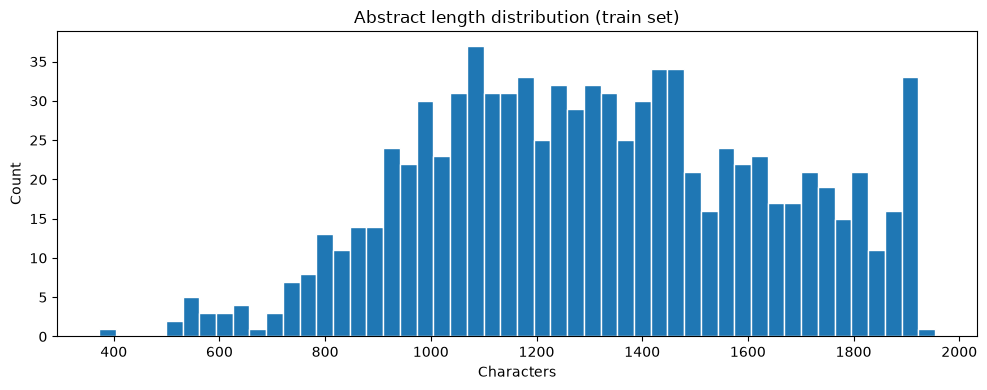

In [4]:
import matplotlib.pyplot as plt

lengths = [len(doc['text']) for doc in train]
df_len = pd.Series(lengths, name='char_length')

print(df_len.describe().to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lengths, bins=50, edgecolor='white')
ax.set_xlabel('Characters')
ax.set_ylabel('Count')
ax.set_title('Abstract length distribution (train set)')
plt.tight_layout()
plt.show()

## Publish date distribution

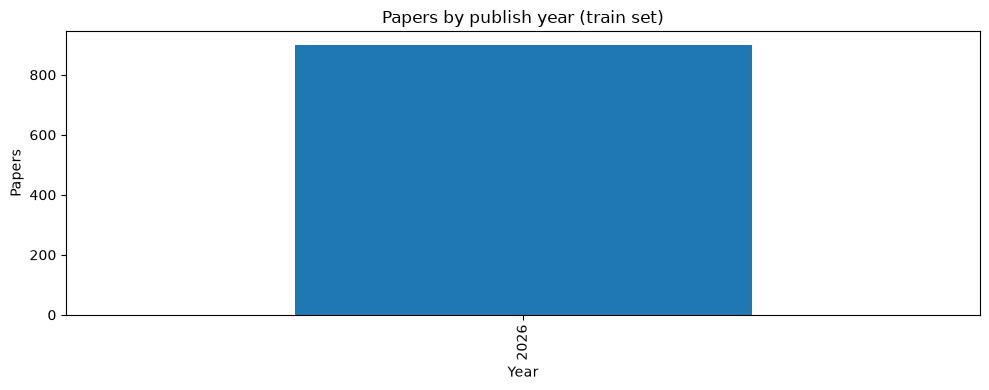

In [5]:
years = [doc['published'][:4] for doc in train]
year_counts = pd.Series(years).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
year_counts.plot(kind='bar', ax=ax)
ax.set_xlabel('Year')
ax.set_ylabel('Papers')
ax.set_title('Papers by publish year (train set)')
plt.tight_layout()
plt.show()

## Shortest and longest abstracts

In [6]:
sorted_docs = sorted(train, key=lambda d: len(d['text']))

print("=== 3 SHORTEST ===")
for doc in sorted_docs[:3]:
    print(f"[{len(doc['text'])} chars] {doc['title']}")
    print(doc['text'])
    print()

print("=== 3 LONGEST ===")
for doc in sorted_docs[-3:]:
    print(f"[{len(doc['text'])} chars] {doc['title']}")
    print(doc['text'][:500], '...')
    print()

=== 3 SHORTEST ===
[372 chars] Efficient cooling by ferroelectric or ferromagnetic hysteresis loops
An efficient cooling effect is put forward, by means of external electric or magnetic fields along hysteresis loops. A simplified model of hysteresis is used for numerical illustration. The model is based upon a second-order expansion of the energy in powers of polarization and external field. The electrocaloric effect along hysteresis loops is discussed for comparison.

[503 chars] Sub-10 mK "In-cell" Magnetic Refrigeration for Cryogen-free Cryostats
A design and implementation of "in-cell" magnetic refrigeration to achieve sub-10 mK temperatures T in cryogen-free dilution refrigerators is presented. The ultra low temperatures below 5 mK are attained in finite magnetic fields B up to 1 T. The holding time below 5 mK varies between about 3 to 30 hours, depending on the final magnetic field after demagnetization process. The developed technique can be used to study low dimensional devices